In [ ]:
import pandas as pd

df = pd.read_csv("../data/raw/raw_analyst_ratings.csv")
df.head()


,Unnamed: 0,headline,url,publisher,date,stock
0,0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 10:30:54-04:00,A
1,1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 10:45:20-04:00,A
2,2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 04:30:07-04:00,A
3,3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 12:45:06-04:00,A
4,4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 11:38:59-04:00,A


In [2]:
df.columns


Index(['Unnamed: 0', 'headline', 'url', 'publisher', 'date', 'stock'], dtype='str')

In [3]:
df['headline_length'] = df['headline'].apply(len)

In [4]:
df['headline_length'].describe()

count    1.407328e+06
mean     7.312051e+01
std      4.073531e+01
min      3.000000e+00
25%      4.700000e+01
50%      6.400000e+01
75%      8.700000e+01
max      5.120000e+02
Name: headline_length, dtype: float64

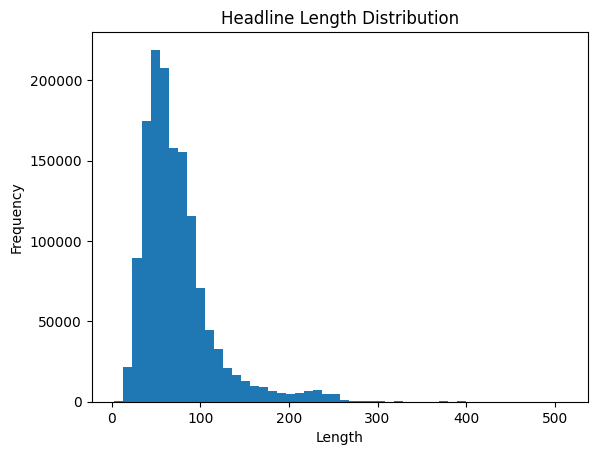

In [5]:
import matplotlib.pyplot as plt

plt.hist(df['headline_length'], bins=50)
plt.title("Headline Length Distribution")
plt.xlabel("Length")
plt.ylabel("Frequency")
plt.show()

In [6]:
publisher_counts = df['publisher'].value_counts()
publisher_counts.head(10)

publisher
Paul Quintaro        228373
Lisa Levin           186979
Benzinga Newsdesk    150484
Charles Gross         96732
Monica Gerson         82380
Eddie Staley          57254
Hal Lindon            49047
ETF Professor         28489
Juan Lopez            28438
Benzinga Staff        28114
Name: count, dtype: int64

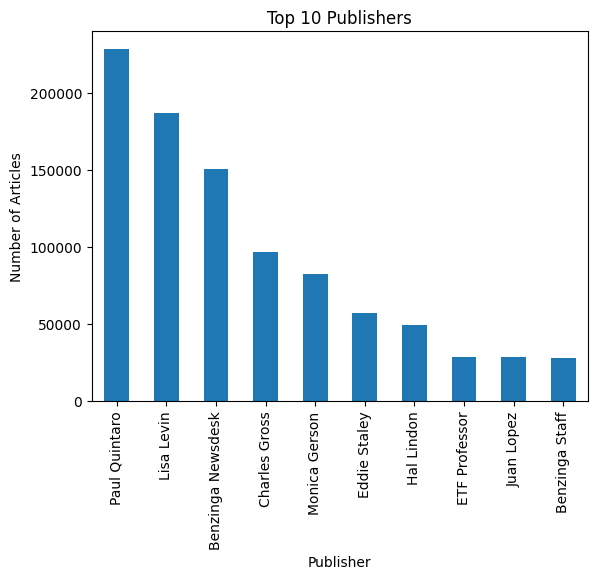

In [7]:
publisher_counts.head(10).plot(kind='bar')
plt.title("Top 10 Publishers")
plt.xlabel("Publisher")
plt.ylabel("Number of Articles")
plt.show()

In [9]:
df['date'] = pd.to_datetime(df['date'], errors='coerce', utc=True)

In [10]:
df['date'].isna().sum()

np.int64(1351341)

In [11]:
df['only_date'] = df['date'].dt.date
daily_news = df.groupby('only_date').size()

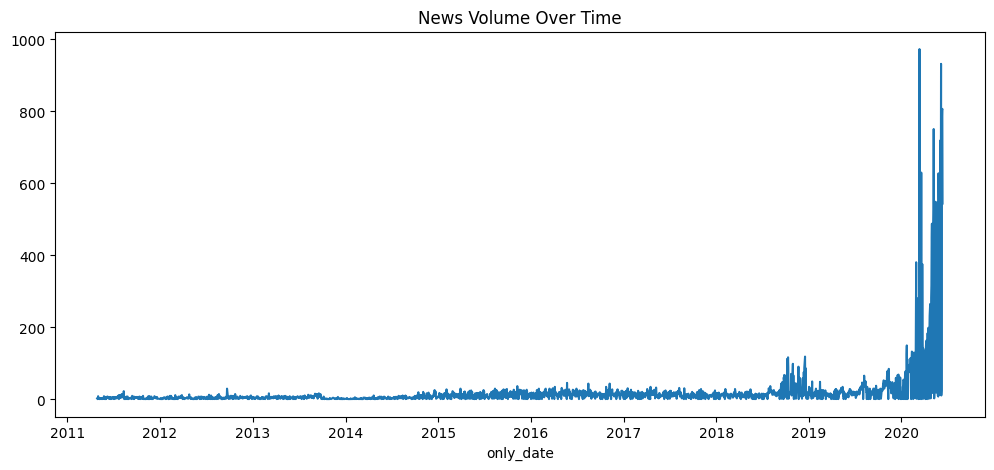

In [12]:
import matplotlib.pyplot as plt

daily_news.plot(figsize=(12,5))
plt.title("News Volume Over Time")
plt.show()

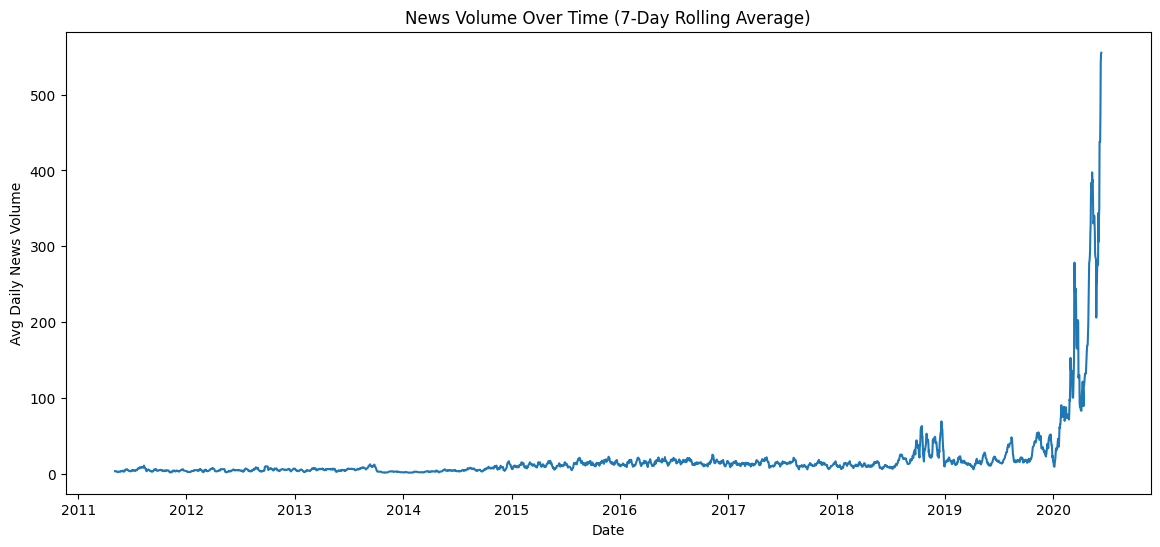

In [13]:
daily_news_7d = daily_news.rolling(window=7).mean()

daily_news_7d.plot(figsize=(14,6))
plt.title("News Volume Over Time (7-Day Rolling Average)")
plt.xlabel("Date")
plt.ylabel("Avg Daily News Volume")
plt.show()

In [ ]:
import pandas as pd
import re

df['headline'] = df['headline'].astype(str)

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)  
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['clean_headline'] = df['headline'].apply(clean_text)

In [16]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(stop_words='english', max_features=20)

X = vectorizer.fit_transform(df['clean_headline'])

word_counts = X.toarray().sum(axis=0)

keywords = pd.DataFrame({
    'word': vectorizer.get_feature_names_out(),
    'count': word_counts
}).sort_values(by='count', ascending=False)

keywords

,word,count
18,vs,162147
14,stocks,161868
6,est,140606
5,eps,128929
13,shares,114209
11,reports,108707
16,update,91680
7,market,90880
4,earnings,87185
12,sales,79526


In [18]:
from sklearn.feature_extraction.text import CountVectorizer
import numpy as np
import pandas as pd

vectorizer = CountVectorizer(stop_words='english', max_features=20)

X = vectorizer.fit_transform(df['clean_headline'])

word_counts = np.asarray(X.sum(axis=0)).flatten()

keywords = pd.DataFrame({
    'word': vectorizer.get_feature_names_out(),
    'count': word_counts
}).sort_values(by='count', ascending=False)

keywords

,word,count
18,vs,162147
14,stocks,161868
6,est,140606
5,eps,128929
13,shares,114209
11,reports,108707
16,update,91680
7,market,90880
4,earnings,87185
12,sales,79526


In [20]:
df_sample = df.sample(50000, random_state=42)  # adjust if needed

In [21]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

df_sample['clean_headline'] = df_sample['clean_headline'].astype(str)
df_sample = df_sample[df_sample['clean_headline'].str.len() > 0]

vectorizer = CountVectorizer(
    stop_words='english',
    max_features=500   # reduce for speed
)

X = vectorizer.fit_transform(df_sample['clean_headline'])

lda = LatentDirichletAllocation(
    n_components=5,
    random_state=42,
    learning_method='online',   
    max_iter=10
)

lda.fit(X)

words = vectorizer.get_feature_names_out()

In [22]:
def show_topics(model, feature_names, n_words=10):
    for idx, topic in enumerate(model.components_):
        print(f"\nTopic {idx+1}")
        top_words = [feature_names[i] for i in topic.argsort()[-n_words:]]
        print(", ".join(top_words))

show_topics(lda, words)


Topic 1
upgrades, initiates, downgrades, raises, maintains, target, price, buy, announces, pt

Topic 2
sector, alert, option, etf, financial, stock, markets, etfs, scheduled, earnings

Topic 3
adj, revenue, fy, sees, benzingas, sales, reports, eps, est, vs

Topic 4
midday, moving, says, market, session, higher, update, trading, stocks, shares

Topic 5
set, highs, hit, movers, yesterday, biggest, estimate, new, week, stocks


In [23]:
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df = df.dropna(subset=['date'])

In [24]:
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.to_period('M')
df['hour'] = df['date'].dt.hour
df['day'] = df['date'].dt.date

C:\Users\YOGA 9I\AppData\Local\Temp\ipykernel_23556\1589698017.py:2: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df['month'] = df['date'].dt.to_period('M')


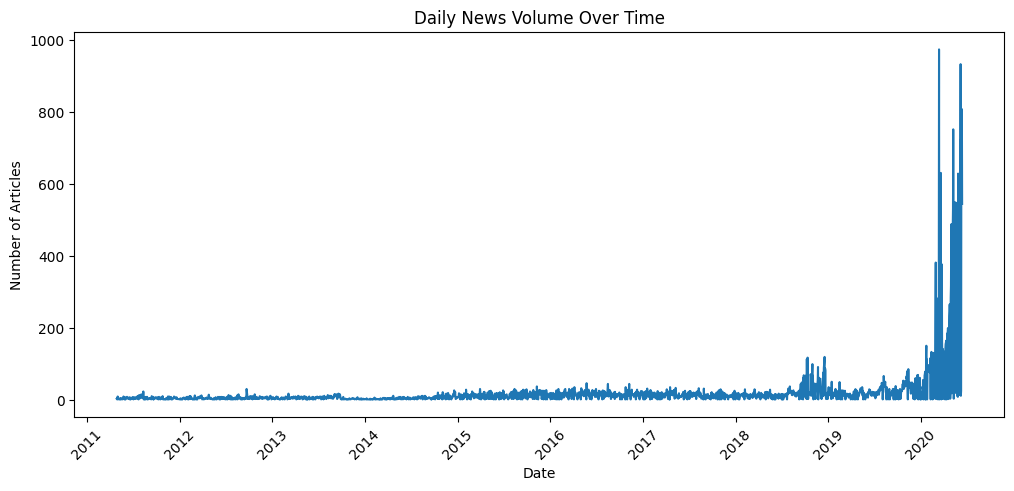

In [25]:
import matplotlib.pyplot as plt

daily_news = df.groupby('day').size()

plt.figure(figsize=(12,5))
plt.plot(daily_news.index, daily_news.values)
plt.title("Daily News Volume Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Articles")
plt.xticks(rotation=45)
plt.show()

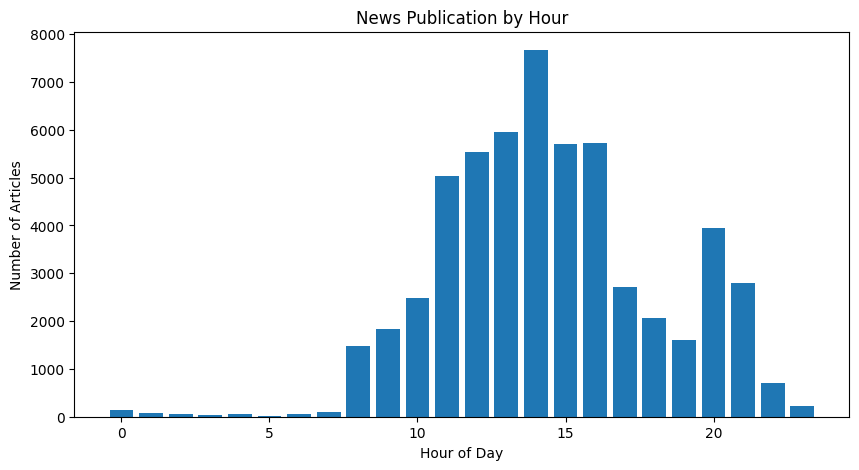

In [26]:
hourly = df.groupby('hour').size()

plt.figure(figsize=(10,5))
plt.bar(hourly.index, hourly.values)
plt.title("News Publication by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Articles")
plt.show()

In [27]:
top_publishers = df['publisher'].value_counts().head(20)
print(top_publishers)

publisher
Benzinga Newsdesk          14750
Lisa Levin                 12408
ETF Professor               4362
Paul Quintaro               4212
Benzinga Newsdesk           3177
Benzinga Insights           2332
Vick Meyer                  2128
Charles Gross               1790
Hal Lindon                  1470
Benzinga_Newsdesk           1239
Eddie Staley                1003
vishwanath@benzinga.com      924
Shanthi Rexaline             887
Monica Gerson                611
Wayne Duggan                 465
Nelson Hem                   345
Jayson Derrick               337
Craig Jones                  310
luke@benzinga.com            271
Javier Hasse                 250
Name: count, dtype: int64


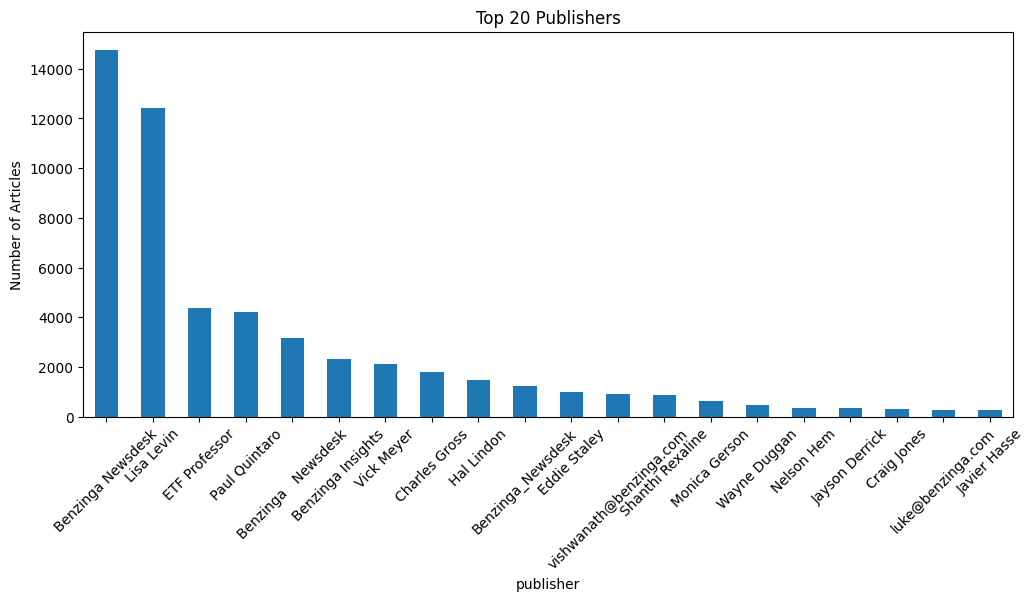

In [28]:
top_publishers.plot(kind='bar', figsize=(12,5))
plt.title("Top 20 Publishers")
plt.ylabel("Number of Articles")
plt.xticks(rotation=45)
plt.show()

In [29]:
def extract_domain(publisher):
    if '@' in publisher:
        return publisher.split('@')[-1]
    return publisher

df['publisher_domain'] = df['publisher'].apply(extract_domain)

domain_counts = df['publisher_domain'].value_counts().head(20)
domain_counts

publisher_domain
Benzinga Newsdesk    14750
Lisa Levin           12408
ETF Professor         4362
Paul Quintaro         4212
Benzinga Newsdesk     3177
Benzinga Insights     2332
Vick Meyer            2128
Charles Gross         1790
Hal Lindon            1470
Benzinga_Newsdesk     1239
benzinga.com          1196
Eddie Staley          1003
Shanthi Rexaline       887
Monica Gerson          611
Wayne Duggan           465
Nelson Hem             345
Jayson Derrick         337
Craig Jones            310
Javier Hasse           250
Luke J Jacobi          166
Name: count, dtype: int64

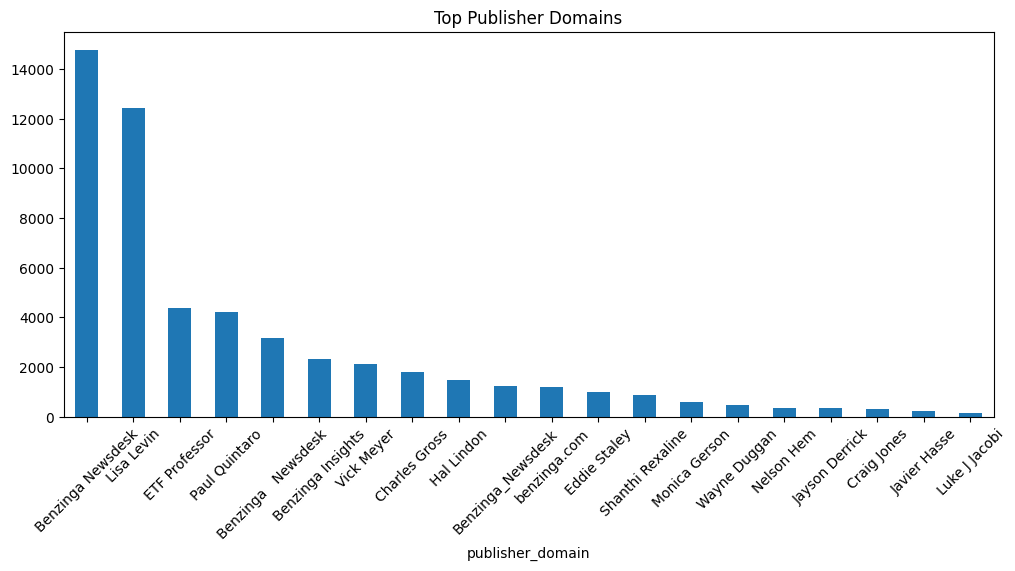

In [30]:
domain_counts.plot(kind='bar', figsize=(12,5))
plt.title("Top Publisher Domains")
plt.xticks(rotation=45)
plt.show()

In [31]:
df.shape

(55987, 14)

In [32]:
df.isnull().sum()

Unnamed: 0          0
headline            0
url                 0
publisher           0
date                0
stock               0
headline_length     0
only_date           0
clean_headline      0
year                0
month               0
hour                0
day                 0
publisher_domain    0
dtype: int64

In [33]:
show_topics(lda, words)


Topic 1
upgrades, initiates, downgrades, raises, maintains, target, price, buy, announces, pt

Topic 2
sector, alert, option, etf, financial, stock, markets, etfs, scheduled, earnings

Topic 3
adj, revenue, fy, sees, benzingas, sales, reports, eps, est, vs

Topic 4
midday, moving, says, market, session, higher, update, trading, stocks, shares

Topic 5
set, highs, hit, movers, yesterday, biggest, estimate, new, week, stocks
